In [1]:
import numpy as np
import pandas as pd
import pygimli as pg
from pygimli.physics import ert
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.patheffects as PathEffects


In [2]:
# figure plotting preferences 

dpi = 200 # resolution
fs = 20 # fontsize

In [3]:
# range of inversion parameters to test 

lam = np.array([1,3,9,
               3,3,
               3,3])

mstart_mult = np.array([1,1,1,
                  1,1,
                  0.1,10])

err_rel = np.array([0.03,0.03,0.03,
                    0.015,0.06,
                    0.03,0.03])    

In [4]:


def generate_rho_T(pn,fn,pn_bh,x_bh,depth_bh,sensorids,lam,mstart_mult,err_rel):
    

    T_plt_all = []
    R_plt_all = []
    p_f_all = []
    p_uf_all = []
    xth_all = []
    yth_all = []
    contours = []
    
    for j in range(0,len(lam)):
        
        contours_temp = []
        
        # load raw fata

        data_raw = ert.load(pn+fn) 

        survey_name=fn
        plotmodel=True

        # calculate geometric factor and apparent resistivity if not already in data file

        if data_raw.haveData('k')==False:
            data_raw['k'] = ert.createGeometricFactors(data_raw,numerical=True) # include topo in k calculation

        if data_raw.haveData('rhoa')==False:
            if data_raw.haveData('r')==False:
                data_raw['r'] = data_raw['u']/data_raw['i']
            data_raw['rhoa'] = data_raw['r']*data_raw['k'] 

        # some datasets had problematic cables. if so, remove those data points

        if sensorids is not None:
            data_raw.removeSensorIdx(sensorids)

        mgr = ert.ERTManager(data_raw)

        # inversion parameters

        mgr.inv.inv.setBlockyModel(True)

        data_raw['err'] = ert.estimateError(
        data_raw, 
        absoluteError=0.001, 
        relativeError=err_rel[j] # % noise
        )

        # run inversion

        mod = mgr.invert(
            data_raw,
            lam=lam[j],
            startModel=np.median(data_raw['rhoa'])*mstart_mult[j],
        )

        # getting chi2, rms error

        chi2 = mgr.inv.inv.getChi2()
        rms = np.sqrt(np.mean(((data_raw['rhoa']-mgr.inv.response)/data_raw['rhoa'])**2))*100

        # plot results

        fig1, ax1 = plt.subplots(1,1,figsize=[13,5])

        ax, cBar = mgr.showResult(
           mod,
            ax=ax1,
            cMap='turbo_r',
            coverage=mgr.coverage(),
            cMin=100,
            cMax=15000,
            orientation='vertical',
        )

        # colorbar

        cBar.set_label('')
        cBar.ax.tick_params(labelsize=fs-4) 
        cBar.ax.set_title(r'$\rho$ ($\Omega$m)'+ '\n',fontsize=fs,rotation=270, y=0.35,x=5)

        # get axis limits and trim figure automatically

        Ex = np.array(data_raw.sensors()).T[0]
        Ey = np.array(data_raw.sensors()).T[1]
        xmin = min(Ex)
        xmax = max(Ex)
        ymin = mgr.paraDomain.yMin()
        ymax = mgr.paraDomain.yMax()
        trim_ymin = ymin + (ymax-ymin)/3
        ax1.set_ylim([trim_ymin,ymax+abs(ymax-ymin)*0.07])
        ax1.set_xlim([xmin,xmax])

        # figure details - electrodes, rms error, axis labels, borehole location

#         ax1.plot(Ex,Ey,'ko')
        txt = ax1.text(xmin+(xmax-xmin)*0.02,trim_ymin+(ymax-trim_ymin)*0.1,'RMSE=%.1f%%'%(rms),color='k',fontsize=fs)
        ax1.tick_params(axis='both', labelsize=fs-4)
        ax1.set_xlabel('X (m)',fontsize=fs)
        ax1.set_ylabel('Z (m)',fontsize=fs)
        ax1.plot([x_bh,x_bh],[Ey[Ex==x_bh]-depth_bh,Ey[Ex==x_bh]],color='w',linewidth=5,zorder=4)

        # calculate coverage filter from sensitivity (using pygimli script)

        def addCoverageAlpha(coverage, dropThreshold=0.4):

            C = np.asarray(coverage)
            C = C[~np.isnan(C)]
            #    print(np.min(C), np.max(C))

            if (np.min(C) < 0.) | (np.max(C) > 1.) | (np.max(C) < 0.5):

                nn, hh = np.histogram(C, 50)
                nnn = nn.cumsum(axis=0) / float(len(C))

                #        print("min-max nnn ", min(nnn), max(nnn))
                mi = hh[np.min(np.where(nnn > 0.02)[0])]

                if np.min(nnn) > dropThreshold:
                    ma = np.max(C)
                else:
                    ma = hh[np.max(np.where(nnn < dropThreshold)[0])]
        #            mi = hh[min(np.where(nnn > 0.2)[0])]
        #            ma = hh[max(np.where(nnn < 0.7)[0])]

                C = (C - mi) / (ma - mi)
                C[np.where(C < 0.)] = 0.0
                C[np.where(C > 0.95)] = 1.0

            return(C)

        # interpolate results onto regular grid

        E = np.array(data_raw.sensors()).T[0]

        # get values from triangular mesh 

        Xm = np.array(mgr.paraDomain.cellCenters()).T[0]
        Ym = np.array(mgr.paraDomain.cellCenters()).T[1]
        Rm = np.array(mod)

        # make new grid

        xg = np.arange(min(E),max(E)+0.001,min(np.diff(E))/2)
        yg = np.arange(np.round(min(Ym),1),np.round(max(Ym),1)+0.1,0.1)
        [Xg,Yg]=np.meshgrid(xg,yg)

        # interpolate resistivity and coverage onto new grid

        from scipy.interpolate import griddata
        Cov = addCoverageAlpha(mgr.coverage())
        Rg = griddata(np.array( (Xm.flatten(), Ym.flatten()) ).T, Rm.flatten(), np.array((Xg.flatten(), Yg.flatten()) ).T,  method='linear')
        Cg = griddata(np.array( (Xm.flatten(), Ym.flatten()) ).T, Cov.flatten(), np.array((Xg.flatten(), Yg.flatten()) ).T,  method='linear')

        # load borehole data

        data_bh = pd.read_excel(pn_bh)

        z_bh = np.array(data_bh.keys())
        T_bh = data_bh.iloc[0].values

        # find resistivity at borehole loc

        Rhog = np.reshape(Rg,np.shape(Xg))

        y_corr = Yg.T[0]- Ey[np.where(Ex==x_bh)][0] # borehole depth -> elevation
        Rho_bh = Rhog[np.where(Xg==x_bh)]

        R_atT = []

        for i in range(len(z_bh)):
            R_atT.append(Rho_bh[np.where(abs(y_corr-z_bh[i])==min(abs(y_corr-z_bh[i])))[0][0]])

        R_atT = np.array(R_atT)

        R_plt = R_atT[~np.isnan(R_atT)]
        z_plt = z_bh[~np.isnan(R_atT)]
        T_plt = T_bh[~np.isnan(R_atT)]

        # plot temperature resistivity curve

        cmap = plt.get_cmap('rainbow', len(T_plt))

        fig2, ax2 = plt.subplots(1,1,figsize=[6,5])

        for i in range (len(T_plt)):
            plt.scatter(T_plt[i], R_plt[i]/1000,100,color=cmap(i),label='z=%sm'%z_plt[i],zorder=0)

        plt.legend(fontsize=fs-9)

        plt.xlabel(r'Temperature ($\degree$C)',fontsize=fs)
        plt.ylabel(r'Resistivity (k$\Omega$m)',fontsize=fs)

        ax.tick_params(axis='both', which='major', labelsize=fs-2)

        T_th = -0.00 

        # fit T>0 and T<0

        # frozen 

        px_f = T_plt[T_plt<T_th] 
        py_f = R_plt[T_plt<T_th]

        # unfrozen 

        px_uf = T_plt[T_plt>T_th]
        py_uf = R_plt[T_plt>T_th]

        coeff1 = np.poly1d(np.polyfit(px_uf,py_uf, 1)) # unfrozen
        coeff2 = np.poly1d(np.polyfit(px_f,py_f, 1))

        a,b = list(coeff1)
        c,d = list(coeff2)

        # find intersection point of two lines

        xth = (d-b)/(a-c)

        xn = np.linspace(xth,max(T_plt))
        p_uf = np.poly1d(coeff1)
        p_f = np.poly1d(coeff2)

        yth = p_uf(xth)

        # plot lines

        pad = 0.5
        plt.plot(np.linspace(min(T_plt)-pad,xth),p_f(np.linspace(min(T_plt)-pad,xth))/1000,'k--')
        plt.plot(np.linspace(xth,max(T_plt)+pad),p_uf(np.linspace(xth,max(T_plt)+pad))/1000,'k:')

        plt.plot(xth,yth/1000,'k*',markersize=10,)

        plt.text(xth+0.2,yth/1000+0.5,'(%.2f,%.1f)'%(xth,yth/1000),fontsize=fs-2)

        T_plt_all.append(T_plt)
        R_plt_all.append(R_plt)
        p_f_all.append(p_f)
        p_uf_all.append(p_uf)
        xth_all.append(xth)
        yth_all.append(yth)
        
        if j ==1: # i.e., "best estimate" model
            
            cs = ax1.tricontour(
                np.array(mgr.paraDomain.cellCenters()).T[0],
                np.array(mgr.paraDomain.cellCenters()).T[1],
                mgr.model,
                levels=[yth],
                colors='k',
                linewidth=3,
                alpha=1,
                zorder=3          
                  )   

        else: # sensitivity analyis results

            cs = ax1.tricontour(
                np.array(mgr.paraDomain.cellCenters()).T[0],
                np.array(mgr.paraDomain.cellCenters()).T[1],
                mgr.model,
                levels=[yth],
                colors='blueviolet',
                linewidth=3,
                alpha=1,
                zorder=2
                  ) 

        for collection in cs.collections:
            for path in collection.get_paths():
                contours_temp.append(path.vertices.copy())      

        contours.append(contours_temp)
    
    return T_plt_all,R_plt_all,p_f_all,p_uf_all,xth_all,yth_all,mgr,contours

10/04/26 - 12:51:02 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (0.9s x 223): /Users/teddiherringnew/Library/Caches/pygimli/7165247469012375587
10/04/26 - 12:51:02 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:51:02 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:51:02 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:51:02 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:51:02 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:51:02 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:51:02 - pyGIMLi - INFO - Homogeneous starting model set to: 2178.1680818083632


/var/folders/5z/g4c125y952l233l_4lb9yt6c0000gp/T/ipykernel_21147/2825295837.py:259: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cs = ax1.tricontour(
10/04/26 - 12:51:05 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (0.9s x 224): /Users/teddiherringnew/Library/Caches/pygimli/7165247469012375587
10/04/26 - 12:51:05 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:51:05 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:51:05 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:51:05 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:51:05 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:51:05 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:51:05 - pyGIMLi 

/var/folders/5z/g4c125y952l233l_4lb9yt6c0000gp/T/ipykernel_21147/2825295837.py:259: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cs = ax1.tricontour(
10/04/26 - 12:51:10 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (0.9s x 226): /Users/teddiherringnew/Library/Caches/pygimli/7165247469012375587
10/04/26 - 12:51:10 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:51:10 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:51:10 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:51:10 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:51:10 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:51:10 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:51:10 - pyGIMLi 

/var/folders/5z/g4c125y952l233l_4lb9yt6c0000gp/T/ipykernel_21147/2825295837.py:259: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cs = ax1.tricontour(
10/04/26 - 12:51:15 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (0.9s x 228): /Users/teddiherringnew/Library/Caches/pygimli/7165247469012375587
10/04/26 - 12:51:15 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:51:15 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:51:15 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:51:15 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:51:15 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:51:15 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:51:15 - pyGIMLi 

/var/folders/5z/g4c125y952l233l_4lb9yt6c0000gp/T/ipykernel_21147/2825295837.py:259: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cs = ax1.tricontour(
10/04/26 - 12:51:18 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (0.9s x 229): /Users/teddiherringnew/Library/Caches/pygimli/7165247469012375587
10/04/26 - 12:51:18 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:51:18 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:51:18 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:51:18 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:51:18 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:51:18 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:51:18 - pyGIMLi 

/var/folders/5z/g4c125y952l233l_4lb9yt6c0000gp/T/ipykernel_21147/2825295837.py:259: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cs = ax1.tricontour(


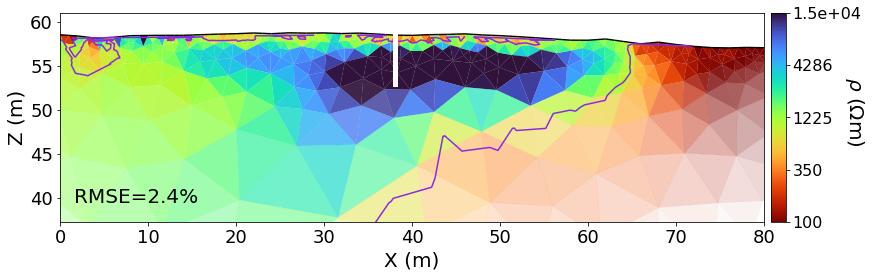

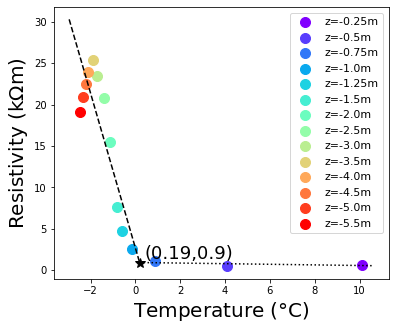

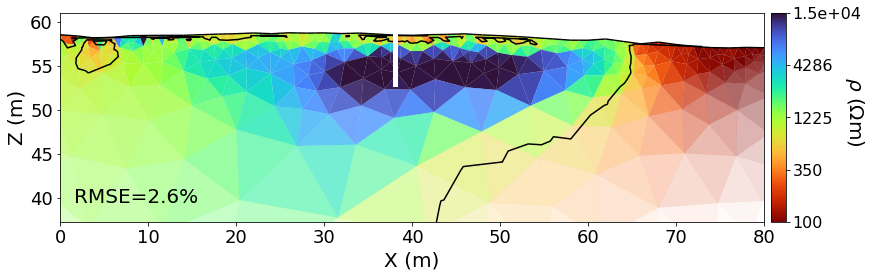

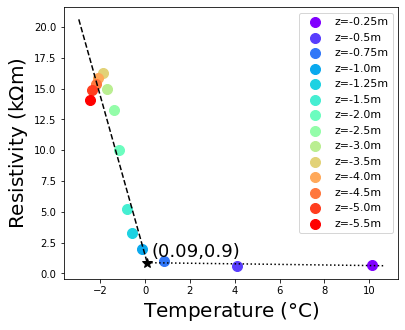

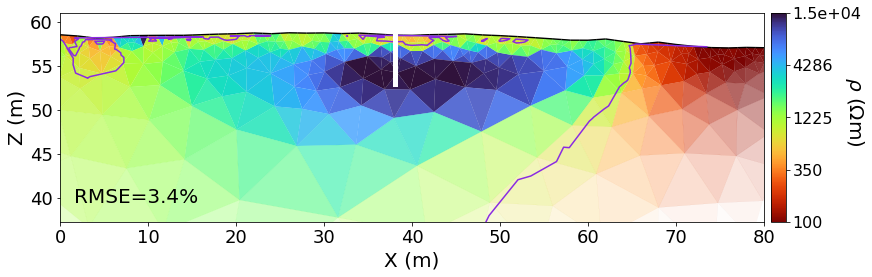

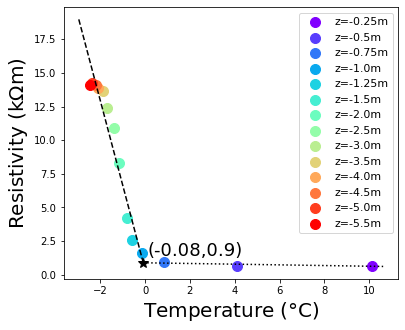

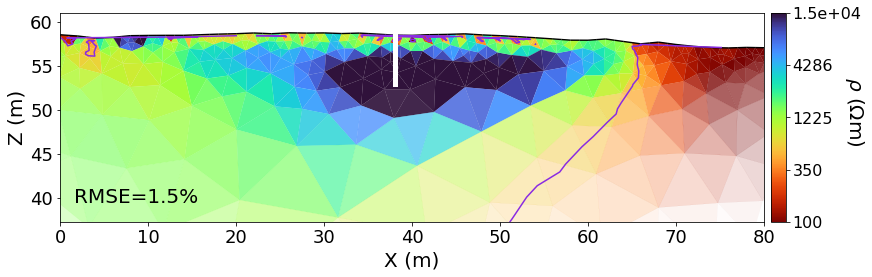

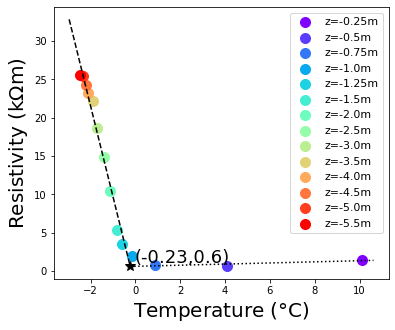

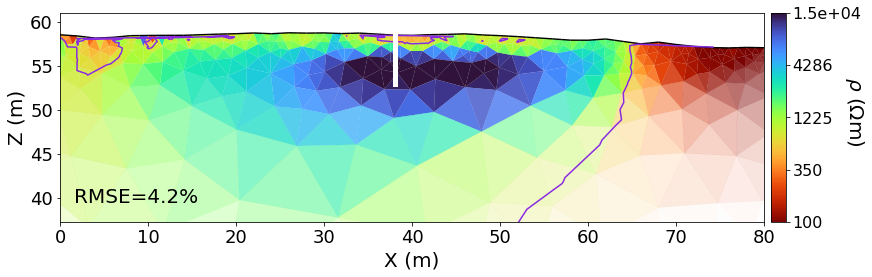

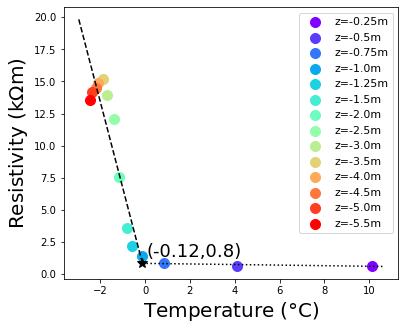

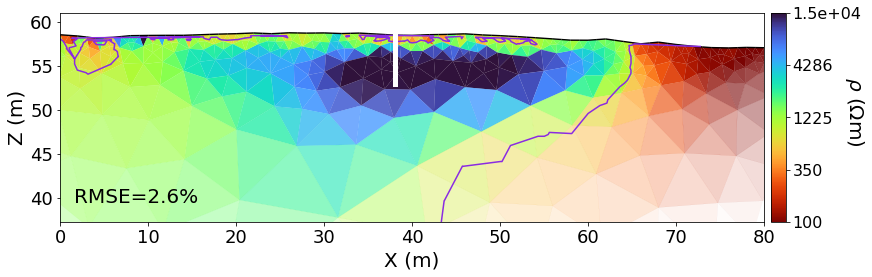

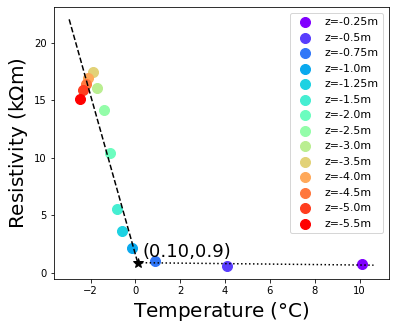

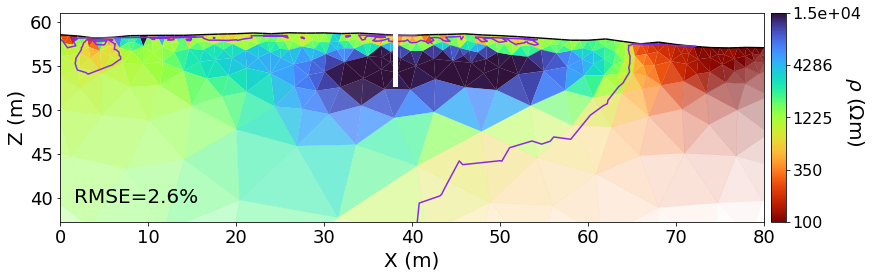

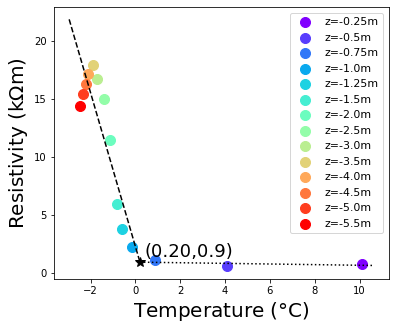

In [5]:

T_ches,R_ches,p_f_ches,p_uf_ches,x_th_ches,y_th_ches,mgr_ches,contours_ches = generate_rho_T(
    pn = '../formatted ert data/summer 2024/',
    fn = 'CHESWenner_1-2024-09-02-200930.txt',
    pn_bh = '../borehole data/chesnaye_sept1_2024_1pm.xlsx',
    x_bh = 38,
    depth_bh = 5.5,
    sensorids = None,
    lam=lam,
    mstart_mult=mstart_mult,
    err_rel=err_rel
    
)

In [6]:
# get best estimate model

j=1 

pn = '../formatted ert data/summer 2024/'
fn = 'CHESWenner_1-2024-09-02-200930.txt'
x_bh = 38
depth_bh = 5.5
sensorids = None

data_raw = ert.load(pn+fn) 

# calculate geometric factor and apparent resistivity if not already in data file

if data_raw.haveData('k')==False:
    data_raw['k'] = ert.createGeometricFactors(data_raw,numerical=True) # include topo in k calculation

if data_raw.haveData('rhoa')==False:
    if data_raw.haveData('r')==False:
        data_raw['r'] = data_raw['u']/data_raw['i']
    data_raw['rhoa'] = data_raw['r']*data_raw['k'] 

# some datasets had problematic cables. if so, remove those data points

if sensorids is not None:
    data_raw.removeSensorIdx(sensorids)

mgr = ert.ERTManager(data_raw)

# inversion parameters

mgr.inv.inv.setBlockyModel(True)

data_raw['err'] = ert.estimateError(
data_raw, 
absoluteError=0.001, 
relativeError=err_rel[j] # % noise
)

# run inversion

mod = mgr.invert(
    data_raw,
    lam=lam[j],
    startModel=np.median(data_raw['rhoa'])*mstart_mult[j],
)

# getting chi2, rms error

chi2 = mgr.inv.inv.getChi2()
rms = np.sqrt(np.mean(((data_raw['rhoa']-mgr.inv.response)/data_raw['rhoa'])**2))*100



10/04/26 - 12:51:23 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (0.9s x 230): /Users/teddiherringnew/Library/Caches/pygimli/7165247469012375587
10/04/26 - 12:51:23 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:51:23 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:51:23 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:51:23 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:51:23 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:51:23 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:51:23 - pyGIMLi - INFO - Homogeneous starting model set to: 2178.1680818083632


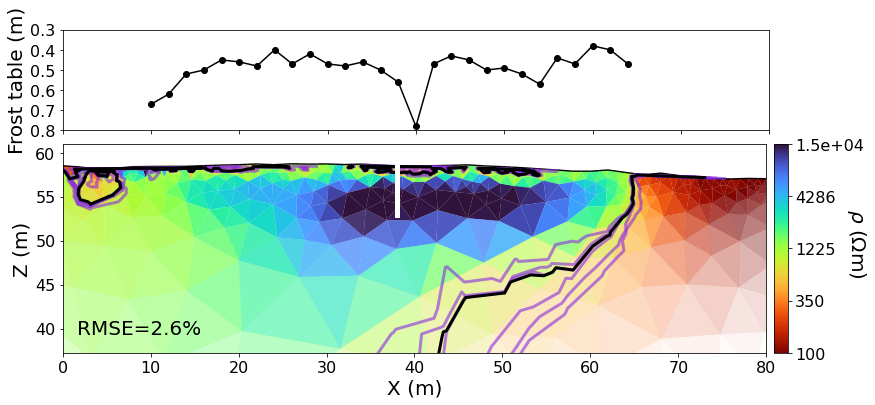

In [7]:
# plot ensemble interpretation

fig1, ax1 = plt.subplots(1,1,figsize=[13,5])

ax, cBar = mgr.showResult(
   mod,
    ax=ax1,
    cMap='turbo_r',
    coverage=mgr.coverage(),
    cMin=100,
    cMax=15000,
    orientation='vertical',
)

# colorbar

cBar.set_label('')
cBar.ax.tick_params(labelsize=fs-4) 
cBar.ax.set_title(r'$\rho$ ($\Omega$m)'+ '\n',fontsize=fs,rotation=270, y=0.35,x=5)

# get axis limits and trim figure automatically

Ex = np.array(data_raw.sensors()).T[0]
Ey = np.array(data_raw.sensors()).T[1]
xmin = min(Ex)
xmax = max(Ex)
ymin = mgr.paraDomain.yMin()
ymax = mgr.paraDomain.yMax()
trim_ymin = ymin + (ymax-ymin)/3
ax1.set_ylim([trim_ymin,ymax+abs(ymax-ymin)*0.07])
ax1.set_xlim([xmin,xmax])

# figure details - electrodes, rms error, axis labels, borehole location

# ax1.plot(Ex,Ey,'ko')
txt = ax1.text(xmin+(xmax-xmin)*0.02,trim_ymin+(ymax-trim_ymin)*0.1,'RMSE=%.1f%%'%(rms),color='k',fontsize=fs)
ax1.tick_params(axis='both', labelsize=fs-4)
ax1.set_xlabel('X (m)',fontsize=fs)
ax1.set_ylabel('Z (m)',fontsize=fs)
ax1.plot([x_bh,x_bh],[Ey[Ex==x_bh]-depth_bh,Ey[Ex==x_bh]],color='w',linewidth=5,zorder=4)

# plot frozen/unfrozen interface 

for i in range(len(contours_ches)):
    for j in range(len(contours_ches[i])):
        if i ==1 :
            ax1.plot(contours_ches[i][j][:, 0],contours_ches[i][j][:, 1], color='k',linestyle='-',linewidth=3,alpha=1,zorder=3)
        else:
            ax1.plot(contours_ches[i][j][:, 0],contours_ches[i][j][:, 1], color='blueviolet',linestyle='-',linewidth=3,alpha=0.6,zorder=2)

# plot frost table

frost_table = pd.read_excel('../frost tables/CHESWenner_1-2024-09-02-200930.xlsx')   
ft_x = np.array(frost_table['x'])
topo_x = np.array(data_raw.sensors()).T[0]

ft_z = np.array(frost_table['z'])
topo_z = np.array(data_raw.sensors()).T[1]

ft_z = np.where(ft_z==0, np.nan, ft_z) 

ax1 = fig1.add_axes([0.125,0.83,0.755,0.28])
[x,i1,i2] = np.intersect1d(ft_x,topo_x,return_indices=True)
ax1.plot(ft_x,ft_z/100,'ko-')
ax1.set_ylabel('Frost table (m)',fontsize=fs)
plt.gca().invert_yaxis()
ax1.set_xlim([xmin,xmax])
ax1.tick_params(axis='both', labelsize=fs-4)
ax1.tick_params(labelbottom=False)    
ax1.set_ylim([0.8,0.3])
ax1.set_yticks(np.arange(0.3,.81,step=0.1)) ;      
            
fig1.savefig('../inverted results/c4.png',format='png',dpi=dpi,bbox_inches='tight',facecolor='w')


In [8]:
y_th_ches

[928.6718396770394,
 861.3603045754148,
 890.7930701023323,
 581.3586627258763,
 826.4875657317602,
 869.3582555633365,
 900.9042717431744]

In [11]:
y_th_ches[1]

861.3603045754148

In [9]:
min(y_th_ches)

581.3586627258763

In [10]:
max(y_th_ches)

928.6718396770394